# **PROYECTO: INTRODUCCIÓN AL APRENDIZAJE AUTOMÁTICO**

Una vez visto el ***Módulo 5: Introducción al Aprendizaje Automático***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **proyecto integrador**. En este proyecto se verá todo lo aprendido durante el **master en data science**.

Por lo que, el procedimiento a resolver es libre mientras se cumplan los puntos solicitados dentro de la descripción.

Puede descargar el conjunto de datos desde [aquí](https://docs.google.com/spreadsheets/d/1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M/edit?usp=drive_link).

## **ANÁLISIS DE TAMAÑO DE MERCADO DE VEHÍCULOS ELÉCTRICOS**

El análisis del tamaño del mercado es un aspecto crucial de la investigación de mercado que determina el volumen potencial de ventas dentro de un mercado determinado. Ayuda a las empresas a comprender la magnitud de la demanda, evaluar los niveles de saturación del mercado e identificar oportunidades de crecimiento. En este proyecto, Iicill lo llevará a través de la tarea de análisis de tamaño de mercado de Vehículos Eléctricos usando Python.

El análisis de tamaño de mercado para vehículos eléctricos implica un proceso de varios pasos que incluye definir el alcance del mercado, recopilar y preparar datos, modelar analíticamente y comunicar los hallazgos a través de visualización e informes. A continuación se muestra el proceso que puede seguir para la tarea de análisis de tamaño de mercado de vehículos eléctricos:

1.   Definir si el análisis es global, regional o centrado en países específicos.

2.   Recopilar información de asociaciones de la industria, empresas de investigación de mercado (por ejemplo, BloombergNEF, AIE) y publicaciones gubernamentales relevantes para el mercado de EV*.

3.   Utilice datos históricos para identificar tendencias en ventas, producción y mercado de EV*.

4.   Analice el tamaño del mercado y las tasas de crecimiento para diferentes segmentos de EV*.

5.   Según el análisis del tamaño del mercado, proporcione recomendaciones estratégicas para las empresas que buscan ingresar o expandirse en el mercado de EV* a través de predicciones.

_*NOTA: EV significa Electric Vehicles_

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Electric_Vehicle_Population_Data - Electric_Vehicle_Population_Data.csv.csv"

# Load the latest version
df_ev = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "luisdaniel2104/electric-vehicle-pop-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df_ev.head())

/tmp/ipykernel_10347/918715564.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_ev = kagglehub.load_dataset(


100%|██████████| 41.3M/41.3M [00:01<00:00, 23.7MB/s]


First 5 records:    VIN (1-10)     County       City State  Postal Code  Model Year   Make  \
0  5YJYGDEE1L       King    Seattle    WA      98122.0        2020  TESLA   
1  7SAYGDEE9P  Snohomish    Bothell    WA      98021.0        2023  TESLA   
2  5YJSA1E4XK       King    Seattle    WA      98109.0        2019  TESLA   
3  5YJSA1E27G       King   Issaquah    WA      98027.0        2016  TESLA   
4  5YJYGDEE5M     Kitsap  Suquamish    WA      98392.0        2021  TESLA   

     Model           Electric Vehicle Type  \
0  MODEL Y  Battery Electric Vehicle (BEV)   
1  MODEL Y  Battery Electric Vehicle (BEV)   
2  MODEL S  Battery Electric Vehicle (BEV)   
3  MODEL S  Battery Electric Vehicle (BEV)   
4  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible             291   
1  Eligibility unknown as battery range has not b...               0   
2            Clean Alternat

In [3]:
df_ev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

In [4]:
df_ev.head(20)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10
5,3FA6P0SU8H,Thurston,Yelm,WA,98597.0,2017,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21,0,2.0,122057736,POINT (-122.61023 46.94126),PUGET SOUND ENERGY INC,5.306701e+10
6,1N4AZ0CP2D,Yakima,Yakima,WA,98903.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75,0,14.0,150126840,POINT (-120.477805 46.553505),PACIFICORP,5.307700e+10
7,KNAGV4LD9J,Snohomish,Bothell,WA,98012.0,2018,KIA,OPTIMA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,29,0,1.0,290605598,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
8,1N4AZ0CP8F,Kitsap,Port Orchard,WA,98366.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84,0,26.0,137322111,POINT (-122.639265 47.5373),PUGET SOUND ENERGY INC,5.303509e+10
9,5UXTA6C03N,King,Auburn,WA,98001.0,2022,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30,0,47.0,240226332,POINT (-122.2849393 47.3384055),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [5]:
df_ev.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,177861.000000,177866.000000,177866.000000,177866.000000,177477.000000,1.778660e+05,1.778610e+05
mean,98172.453506,2020.515512,58.842162,1073.109363,29.127481,2.202313e+08,5.297672e+10
std,2442.450668,2.989384,91.981298,8358.624956,14.892169,7.584987e+07,1.578047e+09
min,1545.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2019.000000,0.000000,0.000000,18.000000,1.814743e+08,5.303301e+10
50%,98122.000000,2022.000000,0.000000,0.000000,33.000000,2.282522e+08,5.303303e+10
75%,98370.000000,2023.000000,75.000000,0.000000,42.000000,2.548445e+08,5.305307e+10
max,99577.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


Columns with null values and their counts:
 County                    5
City                      5
Postal Code               5
Legislative District    389
Vehicle Location          9
Electric Utility          5
2020 Census Tract         5
dtype: int64


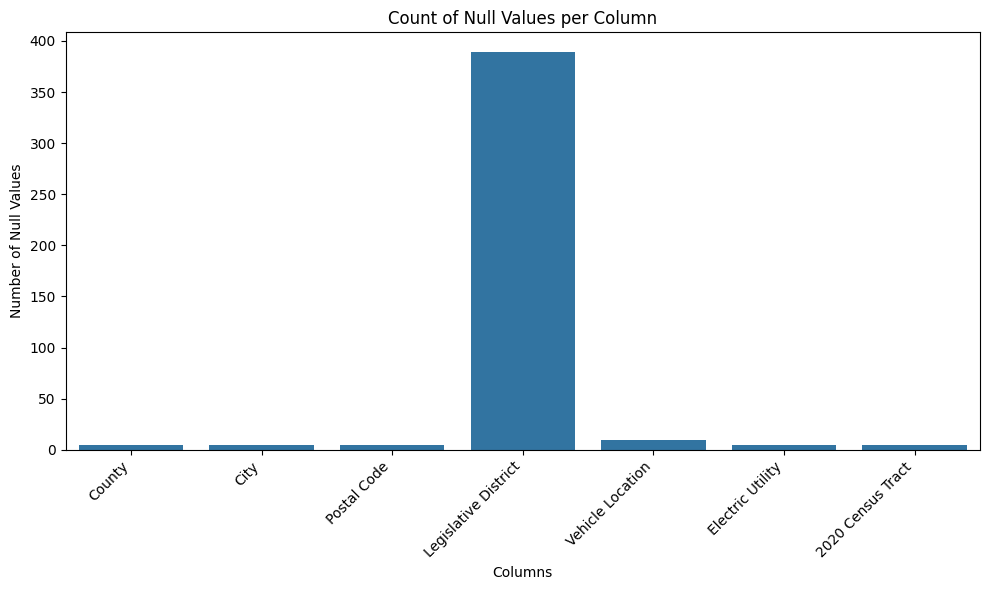

In [6]:
null_values = df_ev.isnull().sum()
null_columns = null_values[null_values > 0]

print("Columns with null values and their counts:\n", null_columns)

plt.figure(figsize=(10, 6))
sns.barplot(x=null_columns.index, y=null_columns.values)
plt.title('Count of Null Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Null Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
print("\n--- Resumen de valores nulos ---")
for col in null_columns.index:
    print(f"\nColumn: {col} (Dtype: {df_ev[col].dtype})")
    print(f"Number of nulls: {null_columns[col]}")
    if df_ev[col].dtype == 'object':
        print("Top 10 values (including nulls):")
        print(df_ev[col].value_counts(dropna=False).head(10))
        print(f"Number of unique values: {df_ev[col].nunique(dropna=False)}")
    else:
        print("Descriptive statistics:")
        print(df_ev[col].describe())



--- Resumen de valores nulos ---

Column: County (Dtype: object)
Number of nulls: 5
Top 10 values (including nulls):
County
King         92740
Snohomish    21001
Pierce       13782
Clark        10416
Thurston      6428
Kitsap        5840
Spokane       4586
Whatcom       4253
Benton        2147
Skagit        1910
Name: count, dtype: int64
Number of unique values: 197

Column: City (Dtype: object)
Number of nulls: 5
Top 10 values (including nulls):
City
Seattle      29447
Bellevue      8931
Redmond       6478
Vancouver     6193
Bothell       5863
Kirkland      5362
Sammamish     5280
Renton        4980
Olympia       4299
Tacoma        3722
Name: count, dtype: int64
Number of unique values: 724

Column: Postal Code (Dtype: float64)
Number of nulls: 5
Descriptive statistics:
count    177861.000000
mean      98172.453506
std        2442.450668
min        1545.000000
25%       98052.000000
50%       98122.000000
75%       98370.000000
max       99577.000000
Name: Postal Code, dtype: float64

In [8]:

columns_to_drop_nulls = [col for col in null_columns.index if col != 'Legislative District']


df_ev_cleaned = df_ev.dropna(subset=columns_to_drop_nulls)
print(f"Shape after dropping nulls from selected columns: {df_ev_cleaned.shape}")


median_legislative_district = df_ev_cleaned['Legislative District'].median()


df_ev_cleaned['Legislative District'] = df_ev_cleaned['Legislative District'].fillna(median_legislative_district)

print(f"Null values in 'Legislative District' after imputation: {df_ev_cleaned['Legislative District'].isnull().sum()}")
print("First 5 rows of the cleaned DataFrame:")
print(df_ev_cleaned.head())

Shape after dropping nulls from selected columns: (177857, 17)
Null values in 'Legislative District' after imputation: 0
First 5 rows of the cleaned DataFrame:
   VIN (1-10)     County       City State  Postal Code  Model Year   Make  \
0  5YJYGDEE1L       King    Seattle    WA      98122.0        2020  TESLA   
1  7SAYGDEE9P  Snohomish    Bothell    WA      98021.0        2023  TESLA   
2  5YJSA1E4XK       King    Seattle    WA      98109.0        2019  TESLA   
3  5YJSA1E27G       King   Issaquah    WA      98027.0        2016  TESLA   
4  5YJYGDEE5M     Kitsap  Suquamish    WA      98392.0        2021  TESLA   

     Model           Electric Vehicle Type  \
0  MODEL Y  Battery Electric Vehicle (BEV)   
1  MODEL Y  Battery Electric Vehicle (BEV)   
2  MODEL S  Battery Electric Vehicle (BEV)   
3  MODEL S  Battery Electric Vehicle (BEV)   
4  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternati

/tmp/ipykernel_10347/3915621608.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ev_cleaned['Legislative District'] = df_ev_cleaned['Legislative District'].fillna(median_legislative_district)


In [9]:
df_ev_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177857 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177857 non-null  object 
 1   County                                             177857 non-null  object 
 2   City                                               177857 non-null  object 
 3   State                                              177857 non-null  object 
 4   Postal Code                                        177857 non-null  float64
 5   Model Year                                         177857 non-null  int64  
 6   Make                                               177857 non-null  object 
 7   Model                                              177857 non-null  object 
 8   Electric Vehicle Type                              177857 non-null  object 
 9 

In [10]:
print("Dataset original:", df_ev.shape)
print("Dataset limpio:", df_ev_cleaned.shape)

missing_values = df_ev_cleaned.isnull().sum().sum()
print("Valores nulos restantes:", missing_values)

Dataset original: (177866, 17)
Dataset limpio: (177857, 17)
Valores nulos restantes: 0


***Limpieza y preparación de datos***

Como primera etapa del proyecto, se realizó una revisión general del conjunto de datos utilizando las funciones `head()`, `info()` y `describe()`, con el objetivo de comprender la estructura, los tipos de datos y las estadísticas descriptivas de las variables disponibles.

Posteriormente, se creó una copia de trabajo denominada `df_ev_cleaned` a partir del dataset original `df_ev`, con el fin de preservar la integridad de los datos fuente y garantizar la reproducibilidad del análisis.

Durante la evaluación de valores faltantes se identificaron registros incompletos en las variables `County`, `City`, `Postal Code`, `Vehicle Location`, `Electric Utility` y `2020 Census Tract`. Debido a que estos casos representaban únicamente 9 registros de un total de 177,866 observaciones (0.0051% del dataset), se optó por eliminarlos, considerando que su impacto estadístico era insignificante.

Asimismo, la variable `Legislative District` presentaba 389 valores faltantes. Dado que esta variable es numérica y los valores ausentes representaban una proporción reducida del total de registros, se realizó una imputación mediante la mediana de la distribución para conservar la mayor cantidad posible de información.

Como resultado del proceso de limpieza, el dataset pasó de 177,866 a 177,857 registros, manteniendo 17 variables y eliminando completamente la presencia de valores nulos. Esto permitió disponer de un conjunto de datos consistente y preparado para las etapas posteriores de análisis exploratorio y modelado.


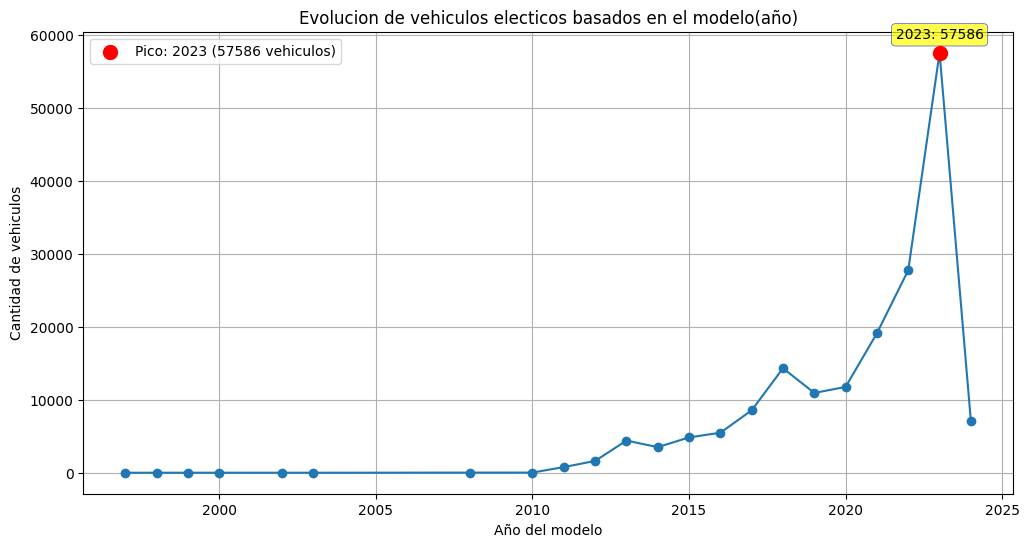

In [11]:
ev_by_year = df_ev_cleaned['Model Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(ev_by_year.index, ev_by_year.values, marker='o')

max_vehicles_year = ev_by_year.idxmax()
max_vehicles_count = ev_by_year.max()


plt.scatter(max_vehicles_year, max_vehicles_count, color='red', s=100, zorder=5, label=f'Pico: {max_vehicles_year} ({max_vehicles_count} vehiculos)')
plt.annotate(f'{max_vehicles_year}: {max_vehicles_count}',
             (max_vehicles_year, max_vehicles_count),
             textcoords="offset points", xytext=(0,10), ha='center',
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=0.5, alpha=0.7))

plt.title('Evolucion de vehiculos electicos basados en el modelo(año)')
plt.xlabel('Año del modelo')
plt.ylabel('Cantidad de vehiculos')
plt.grid(True)
plt.legend()
plt.show()

Se observa que el pico de modelos por año mas usado es 2023, siendo un gran pico que se puede observar, sin embargo, se ve que desde 2020 comienza esta tendencia, pero tambien es importante señalar que en el 2024 se ve una baja considerable, que puede ser atribuida al mes en que cierra el reporte.

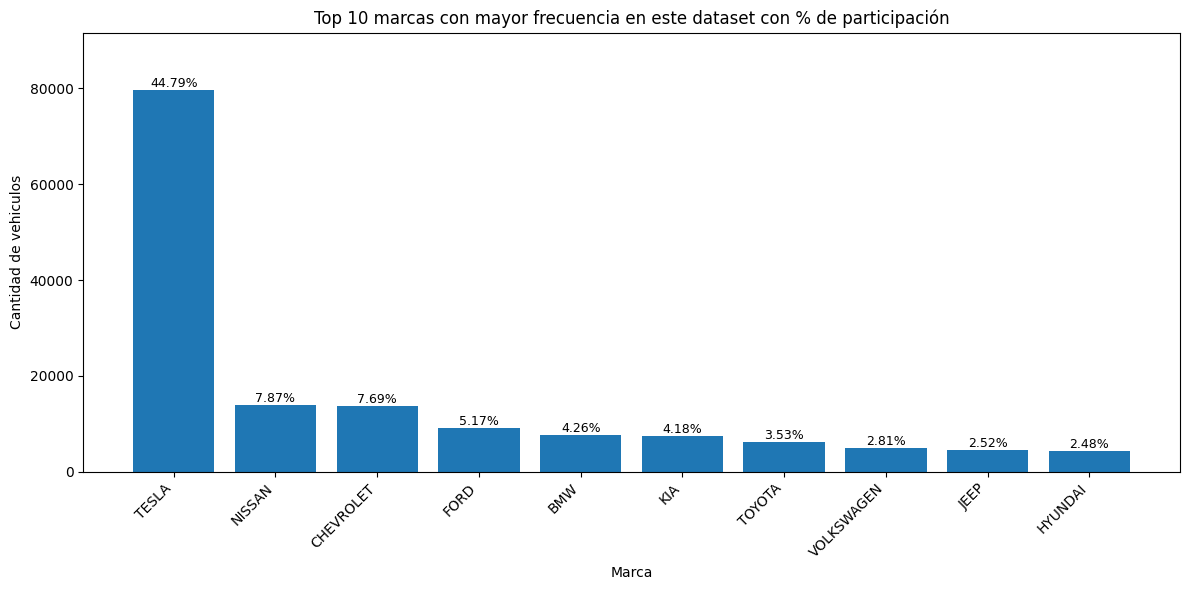

In [12]:
top_makes = df_ev_cleaned['Make'].value_counts().head(10)

plt.figure(figsize=(12,6))

total_vehicles = df_ev_cleaned.shape[0]

bars = plt.bar(top_makes.index, top_makes.values)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_vehicles) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{percentage:.2f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.title('Top 10 marcas con mayor frecuencia en este dataset con % de participación')
plt.xlabel('Marca')
plt.ylabel('Cantidad de vehiculos')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, top_makes.max() * 1.15)
plt.tight_layout()
plt.show()

Se puede observar que tesla domina con un 44.79%, representando casi la mitade del set completo, esto nos puede hacer pensar que el mercado de coches electricos es mayor del de vehiculo convencionales o hibridos enchufables. Veremos que mas datos tiene para nosotros el set.

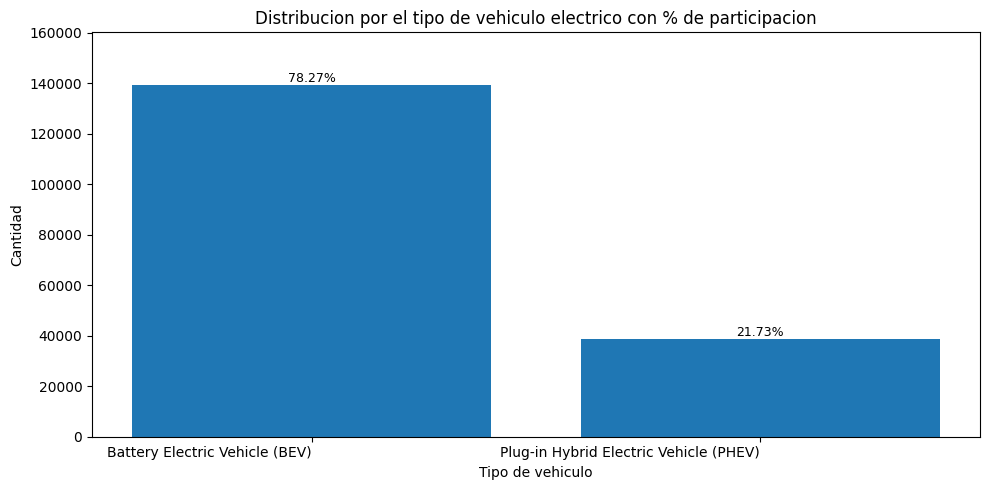

In [15]:
ev_type_counts = df_ev_cleaned['Electric Vehicle Type'].value_counts()

plt.figure(figsize=(10,5))

total_vehicles = df_ev_cleaned.shape[0]

bars = plt.bar(ev_type_counts.index, ev_type_counts.values)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_vehicles) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{percentage:.2f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.title('Distribucion por el tipo de vehiculo electrico con % de participacion')
plt.xlabel('Tipo de vehiculo')
plt.ylabel('Cantidad')
plt.xticks(rotation=0, ha='right')
plt.ylim(0, ev_type_counts.max() * 1.15)
plt.tight_layout()
plt.show()

En este gráfico se observa que el mercado está compuesto principalmente por vehículos totalmente eléctricos (BEV, Battery Electric Vehicles), que representan el 78.27% de los registros, mientras que los vehículos híbridos enchufables (PHEV, Plug-in Hybrid Electric Vehicles) representan el 21.73% restante.

Esta distribución sugiere que la adopción del mercado se inclina cada vez más hacia tecnologías completamente eléctricas, reduciendo la dependencia de motores de combustión interna. Asimismo, esta tendencia ayuda a explicar el fuerte liderazgo de Tesla dentro del dataset, ya que su portafolio está enfocado exclusivamente en vehículos eléctricos de batería. Por otro lado, otros fabricantes tradicionales participan tanto en el segmento de vehículos eléctricos como en otras categorías automotrices, por lo que su presencia dentro del mercado eléctrico aparece más diversificada.

Desde una perspectiva de negocio, estos resultados indican que los consumidores muestran una preferencia creciente por vehículos totalmente eléctricos, lo que podría incentivar a los fabricantes a acelerar la transición desde tecnologías híbridas hacia plataformas completamente eléctricas.


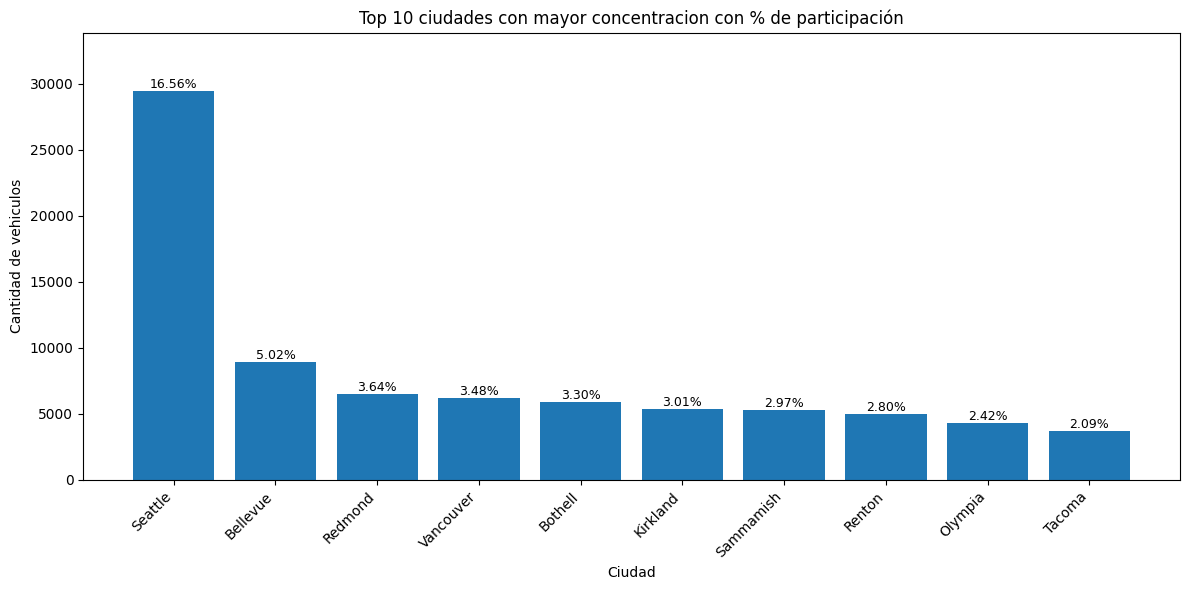

In [19]:
top_cities = df_ev_cleaned["City"].value_counts().head(10)

plt.figure(figsize=(12,6))


total_vehicles = df_ev_cleaned.shape[0]


bars = plt.bar(top_cities.index, top_cities.values)


for bar in bars:
    height = bar.get_height()
    percentage = (height / total_vehicles) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{percentage:.2f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.title('Top 10 ciudades con mayor concentracion con % de participación')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de vehiculos')
plt.xticks(rotation = 45, ha='right')
plt.ylim(0, top_cities.max() * 1.15)
plt.tight_layout()
plt.show()

In [20]:
cafv_counts = df_ev_cleaned['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
cafv_counts

,count
Clean Alternative Fuel Vehicle (CAFV) Eligibility,
Eligibility unknown as battery range has not been researched,91949
Clean Alternative Fuel Vehicle Eligible,66326
Not eligible due to low battery range,19582


In [21]:
cafv_pct = (df_ev_cleaned['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts(normalize = True) * 100)
cafv_pct

,proportion
Clean Alternative Fuel Vehicle (CAFV) Eligibility,
Eligibility unknown as battery range has not been researched,51.698274
Clean Alternative Fuel Vehicle Eligible,37.291757
Not eligible due to low battery range,11.009969


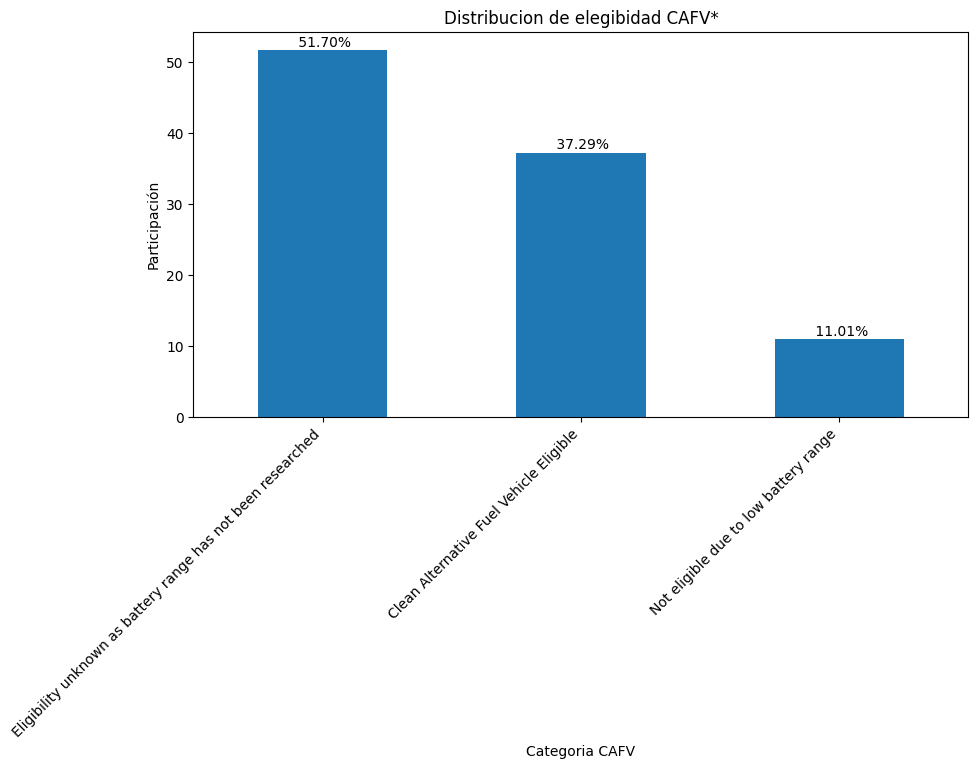

In [23]:
plt.figure(figsize=(10,5))
cafv_pct.plot(kind='bar')
plt.title('Distribucion de elegibidad CAFV*')
plt.xlabel('Categoria CAFV')
plt.ylabel('Participación')
plt.xticks(rotation = 45, ha='right')

for i, value in enumerate(cafv_pct):
  plt.text(i, value + 0.5, f'{value: .2f}%', ha='center')

plt.show()

In [24]:
cafv_by_type = pd.crosstab(
    df_ev_cleaned["Electric Vehicle Type"],
    df_ev_cleaned["Clean Alternative Fuel Vehicle (CAFV) Eligibility"],
    normalize="index"
) * 100

cafv_by_type

Clean Alternative Fuel Vehicle (CAFV) Eligibility,Clean Alternative Fuel Vehicle Eligible,Eligibility unknown as battery range has not been researched,Not eligible due to low battery range
Electric Vehicle Type,,,
Battery Electric Vehicle (BEV),33.940835,66.053418,0.005747
Plug-in Hybrid Electric Vehicle (PHEV),49.359687,0.000000,50.640313


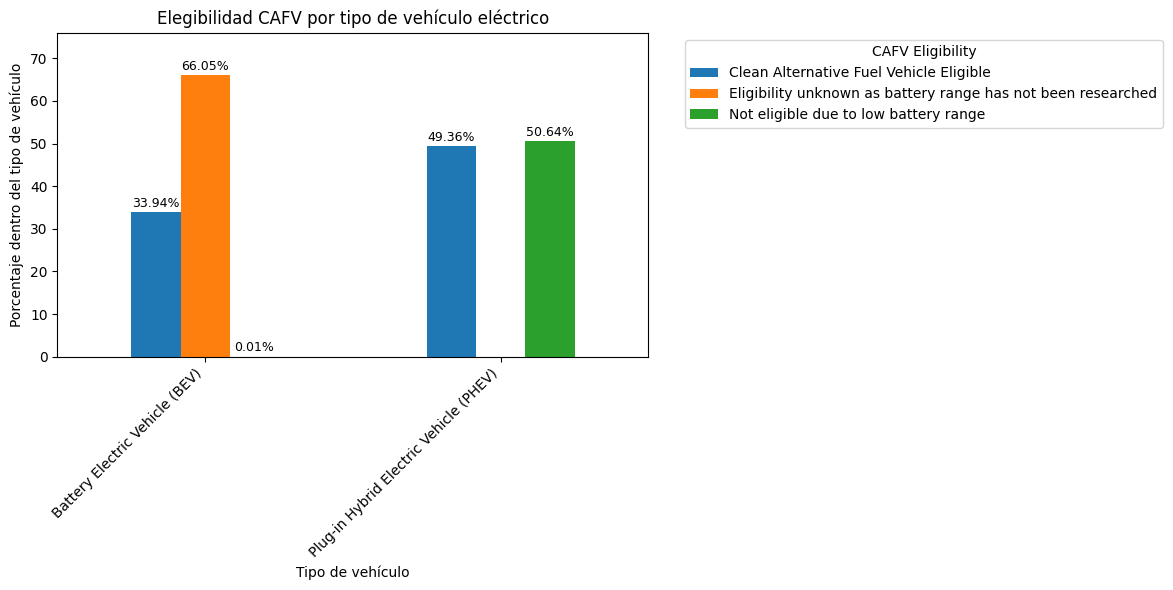

In [27]:
ax = cafv_by_type.plot(kind="bar", figsize=(12,6))

plt.title("Elegibilidad CAFV por tipo de vehículo eléctrico")
plt.xlabel("Tipo de vehículo")
plt.ylabel("Porcentaje dentro del tipo de vehículo")
plt.xticks(rotation=45, ha="right")
plt.legend(title="CAFV Eligibility", bbox_to_anchor=(1.05, 1), loc="upper left")

for col_idx, container in enumerate(ax.containers):
    for row_idx, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            percentage_value = cafv_by_type.iloc[row_idx, col_idx]
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
                    f'{percentage_value:.2f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.ylim(0, cafv_by_type.max().max() * 1.15)
plt.tight_layout()
plt.show()

El análisis cruzado entre el tipo de vehículo y la elegibilidad CAFV revela diferencias significativas entre los vehículos totalmente eléctricos (BEV) y los híbridos enchufables (PHEV). En los BEV, más del 66% de los registros presentan una elegibilidad desconocida, lo que sugiere la existencia de modelos cuya autonomía aún no ha sido evaluada bajo los criterios CAFV. Sin embargo, entre los vehículos BEV clasificados, prácticamente todos resultan elegibles, mientras que los casos no elegibles son insignificantes.

Por otro lado, los vehículos híbridos enchufables muestran una división prácticamente equilibrada entre modelos elegibles (49.36%) y no elegibles (50.64%). Este comportamiento indica que la autonomía eléctrica constituye un factor determinante para la obtención de beneficios asociados a programas de vehículos de energia limpia.

Desde una perspectiva estratégica, los resultados sugieren que los vehículos totalmente eléctricos poseen una mayor probabilidad de cumplir con los criterios regulatorios e incentivos gubernamentales, lo que podría favorecer su adopción futura frente a los híbridos enchufables.

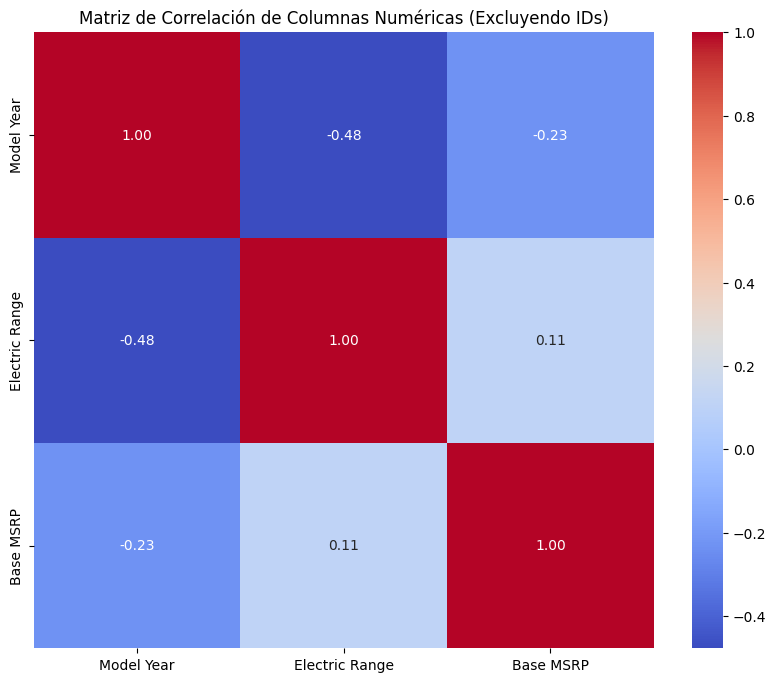

In [28]:
numerical_cols = df_ev_cleaned.select_dtypes(include=['int64', 'float64']).columns


exclude_cols = ['Postal Code', 'Legislative District', 'DOL Vehicle ID', '2020 Census Tract']
filtered_numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

correlation_matrix = df_ev_cleaned[filtered_numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Columnas Numéricas (Excluyendo IDs)')
plt.show()

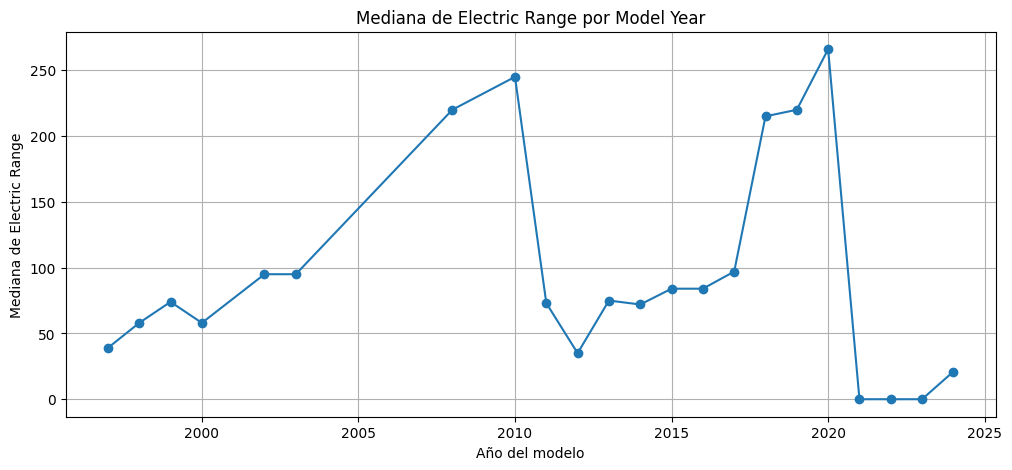

In [29]:
df_ev_cleaned.groupby("Model Year")["Electric Range"].median().plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Mediana de Electric Range por Model Year")
plt.xlabel("Año del modelo")
plt.ylabel("Mediana de Electric Range")
plt.grid(True)
plt.show()

In [30]:
zero_range_by_year = (
    df_ev_cleaned[df_ev_cleaned["Electric Range"] == 0]
    .groupby("Model Year")
    .size()
)

zero_range_by_year

,0
Model Year,
2019,3
2020,62
2021,14763
2022,23445
2023,50403
2024,3273


Durante el análisis de correlación se observó una relación negativa moderada (-0.48) entre Model Year y Electric Range. Sin embargo, un análisis posterior reveló que más de 91 mil registros correspondientes principalmente a modelos recientes presentan una autonomía registrada igual a cero. Esta situación coincide con la categoría "Eligibility unknown as battery range has not been researched" de la variable CAFV, lo que sugiere que el valor cero representa información no investigada o no disponible, y no una autonomía real del vehículo. Por lo tanto, la correlación observada debe interpretarse como un efecto derivado de la calidad de los datos y no necesariamente como una tendencia del mercado.

In [31]:
df_ev_range = df_ev_cleaned[df_ev_cleaned["Electric Range"] > 0]

In [34]:
df_ev_range[['Model Year', 'Electric Range', 'Base MSRP']].corr()

,Model Year,Electric Range,Base MSRP
Model Year,1.000000,-0.059896,-0.199107
Electric Range,-0.059896,1.000000,0.027283
Base MSRP,-0.199107,0.027283,1.000000


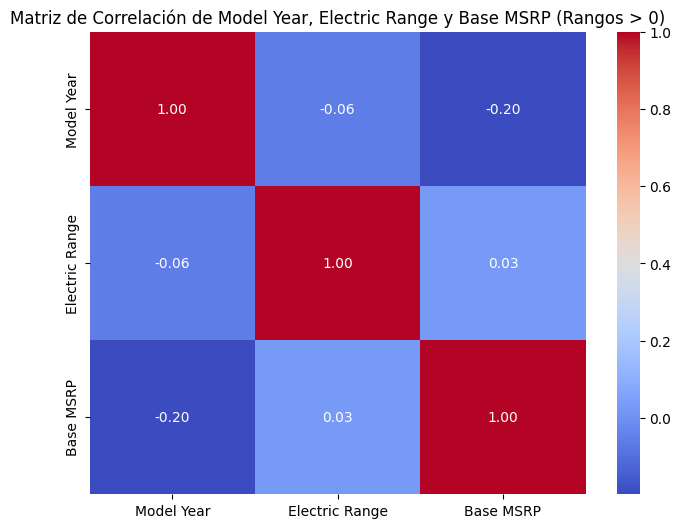

In [35]:
correlation_matrix_filtered = df_ev_range[['Model Year', 'Electric Range', 'Base MSRP']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_filtered, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Model Year, Electric Range y Base MSRP (Rangos > 0)')
plt.show()

Al recalcular la matriz de correlación excluyendo los registros con Electric Range = 0, la relación entre Model Year y Electric Range pasó de -0.48 a -0.06. Esto confirma que la correlación negativa inicial estaba influenciada por registros donde la autonomía eléctrica aparecía como cero, probablemente debido a información no investigada o no disponible.

En esta versión depurada, las variables numéricas analizadas no muestran relaciones lineales fuertes. La correlación entre Electric Range y Base MSRP es prácticamente nula (0.03), lo que sugiere que, dentro de los registros con autonomía válida, un mayor rango eléctrico no necesariamente se asocia con un precio base más alto. Asimismo, la relación entre Model Year y Base MSRP es negativa débil (-0.20), por lo que no puede interpretarse como una tendencia dominante.

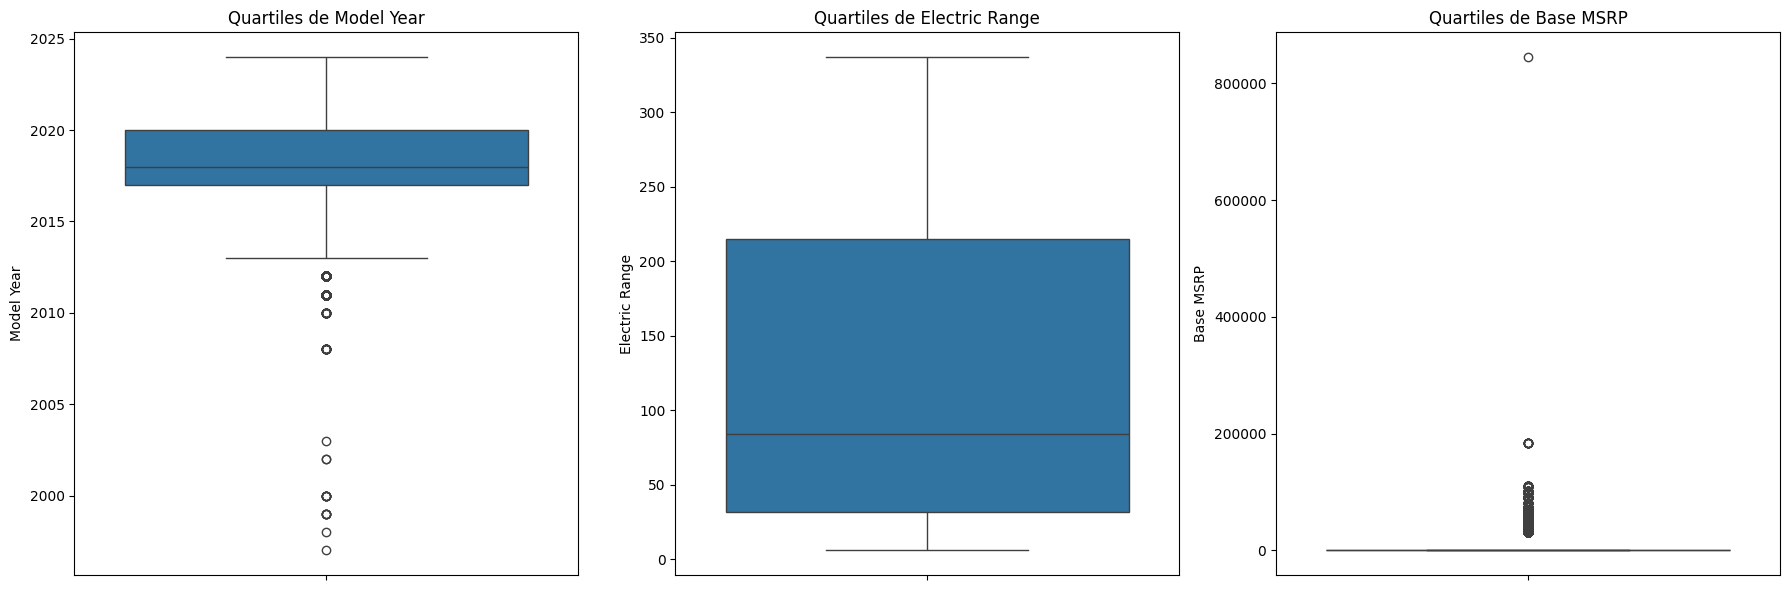

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=df_ev_range['Model Year'], ax=axes[0])
axes[0].set_title('Quartiles de Model Year')
axes[0].set_ylabel('Model Year')

sns.boxplot(y=df_ev_range['Electric Range'], ax=axes[1])
axes[1].set_title('Quartiles de Electric Range')
axes[1].set_ylabel('Electric Range')

sns.boxplot(y=df_ev_range['Base MSRP'], ax=axes[2])
axes[2].set_title('Quartiles de Base MSRP')
axes[2].set_ylabel('Base MSRP')

plt.tight_layout()
plt.show()

In [37]:
df_ev_cleaned["Base MSRP"].describe()

,Base MSRP
count,177857.000000
mean,1072.607319
std,8355.610773
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,845000.000000


In [38]:
df_ev_price = df_ev_cleaned[df_ev_cleaned["Base MSRP"] > 0].copy()

df_ev_price["Base MSRP"].describe()

,Base MSRP
count,3343.000000
mean,57065.725396
std,22787.416865
min,31950.000000
25%,39995.000000
50%,59900.000000
75%,69900.000000
max,845000.000000


In [39]:
valid_price_pct = len(df_ev_price) / len(df_ev_cleaned) * 100

print(f"Registros con Base MSRP válido: {valid_price_pct:.2f}%")

Registros con Base MSRP válido: 1.88%


Aunque el dataset incluye la variable Base MSRP, únicamente el 1.88% de los registros cuenta con información válida. Debido a esta baja cobertura, la variable no sera considerada dentro del análisis principal ni del modelo de aprendizaje automático. Sin embargo, los registros disponibles muestran una mediana de precio de 59,900 USD y una concentración entre 39,995 y 69,900 USD, lo que sugiere que gran parte de los vehículos eléctricos registrados pertenecen a segmentos de precio medio-alto.

In [44]:
adoption_type_year = pd.crosstab(
    df_ev_cleaned["Model Year"],
    df_ev_cleaned["Electric Vehicle Type"]
)

adoption_type_year

Electric Vehicle Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Model Year,,
1997,1,0
1998,1,0
1999,5,0
2000,7,0
2002,2,0
2003,1,0
2008,19,0
2010,20,3
2011,699,76


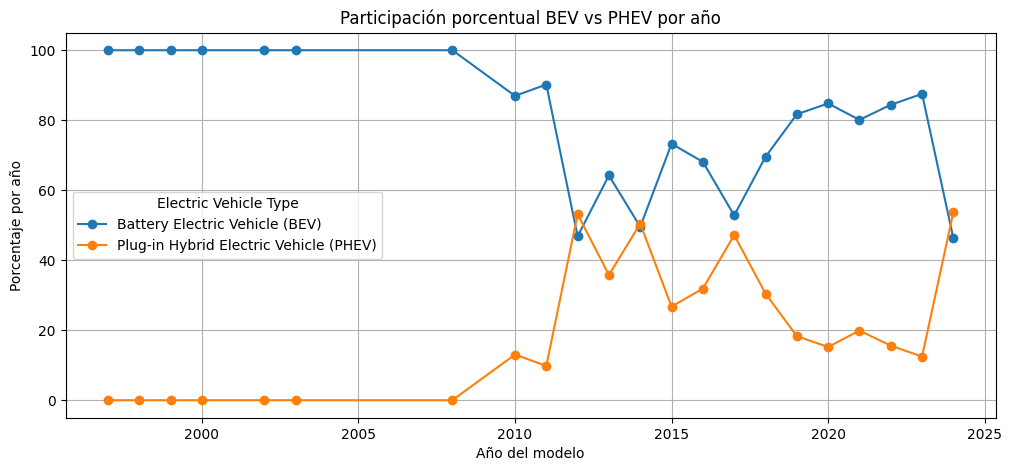

In [45]:
adoption_type_pct = adoption_type_year.apply(lambda x: x / x.sum() * 100, axis=1)

adoption_type_pct.plot(kind="line", marker="o", figsize=(12,5))

plt.title("Participación porcentual BEV vs PHEV por año")
plt.xlabel("Año del modelo")
plt.ylabel("Porcentaje por año")
plt.grid(True)
plt.show()

El crecimiento reciente del mercado está impulsado principalmente por los vehículos completamente eléctricos. En 2023, los BEV alcanzaron 50,403 registros, más del doble que en 2022, mientras que los PHEV crecieron de forma más moderada. Esto sugiere que la adopción del mercado se está inclinando con mayor fuerza hacia vehículos 100% eléctricos, en lugar de híbridos enchufables.

El dato de 2024 debe interpretarse con cautela, ya que probablemente corresponde a un año incompleto dentro del dataset. Por esta razón, no debe considerarse como evidencia de una caída real en la adopción.

In [46]:
adoption_cafv_year = pd.crosstab(
    df_ev_cleaned["Model Year"],
    df_ev_cleaned["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]
)

adoption_cafv_year

Clean Alternative Fuel Vehicle (CAFV) Eligibility,Clean Alternative Fuel Vehicle Eligible,Eligibility unknown as battery range has not been researched,Not eligible due to low battery range
Model Year,,,
1997,1,0,0
1998,1,0,0
1999,5,0,0
2000,7,0,0
2002,2,0,0
2003,1,0,0
2008,19,0,0
2010,23,0,0
2011,775,0,0


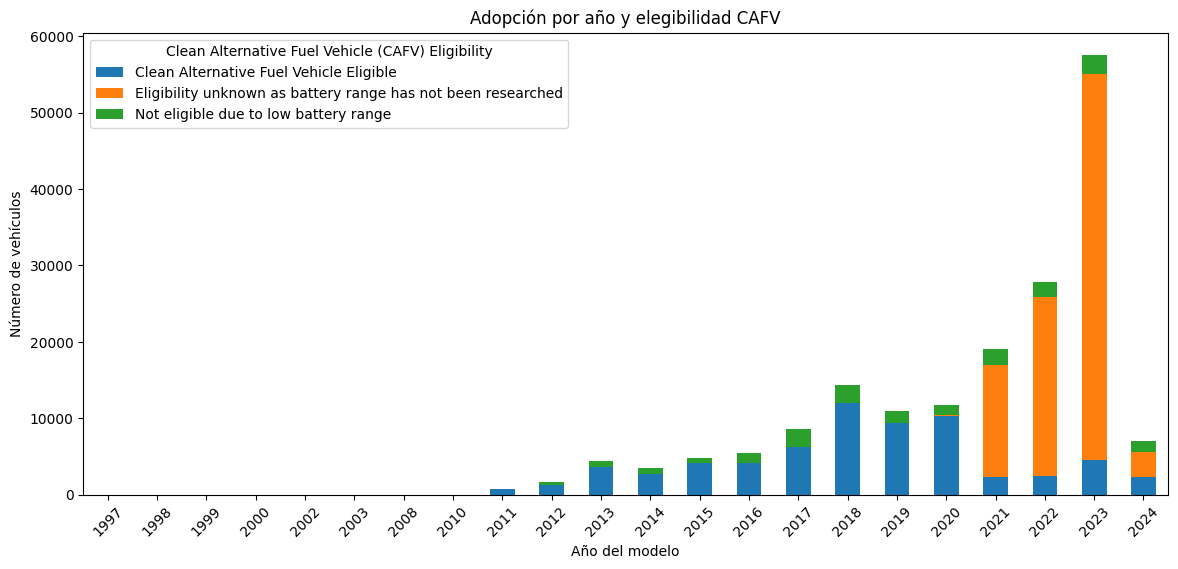

In [47]:
adoption_cafv_year.plot(kind="bar", stacked=True, figsize=(14,6))

plt.title("Adopción por año y elegibilidad CAFV")
plt.xlabel("Año del modelo")
plt.ylabel("Número de vehículos")
plt.xticks(rotation=45)
plt.show()

El análisis de elegibilidad CAFV por año muestra un cambio importante a partir de 2021. En los años previos, la mayoría de los vehículos se clasificaban como elegibles o no elegibles. Sin embargo, desde 2021 aparece una concentración elevada de registros con elegibilidad desconocida debido a que el rango de batería no ha sido investigado.

Este comportamiento coincide con el crecimiento acelerado de los vehículos BEV en los años recientes, especialmente en 2022 y 2023. Por lo tanto, la categoría “unknown” no debe interpretarse como falta de adopción o baja competitividad, sino como una limitación de actualización del dataset respecto a modelos eléctricos recientes.

En términos de mercado, el incremento de registros recientes sigue apuntando a una mayor adopción de vehículos completamente eléctricos, aunque algunas variables técnicas, como Electric Range y CAFV Eligibility, presentan limitaciones para evaluar con precisión la elegibilidad de los modelos más nuevos.

In [48]:
cafv_by_year_pct = pd.crosstab(
    df_ev_cleaned["Model Year"],
    df_ev_cleaned["Clean Alternative Fuel Vehicle (CAFV) Eligibility"],
    normalize="index"
) * 100

cafv_by_year_pct

Clean Alternative Fuel Vehicle (CAFV) Eligibility,Clean Alternative Fuel Vehicle Eligible,Eligibility unknown as battery range has not been researched,Not eligible due to low battery range
Model Year,,,
1997,100.000000,0.000000,0.000000
1998,100.000000,0.000000,0.000000
1999,100.000000,0.000000,0.000000
2000,100.000000,0.000000,0.000000
2002,100.000000,0.000000,0.000000
2003,100.000000,0.000000,0.000000
2008,100.000000,0.000000,0.000000
2010,100.000000,0.000000,0.000000
2011,100.000000,0.000000,0.000000


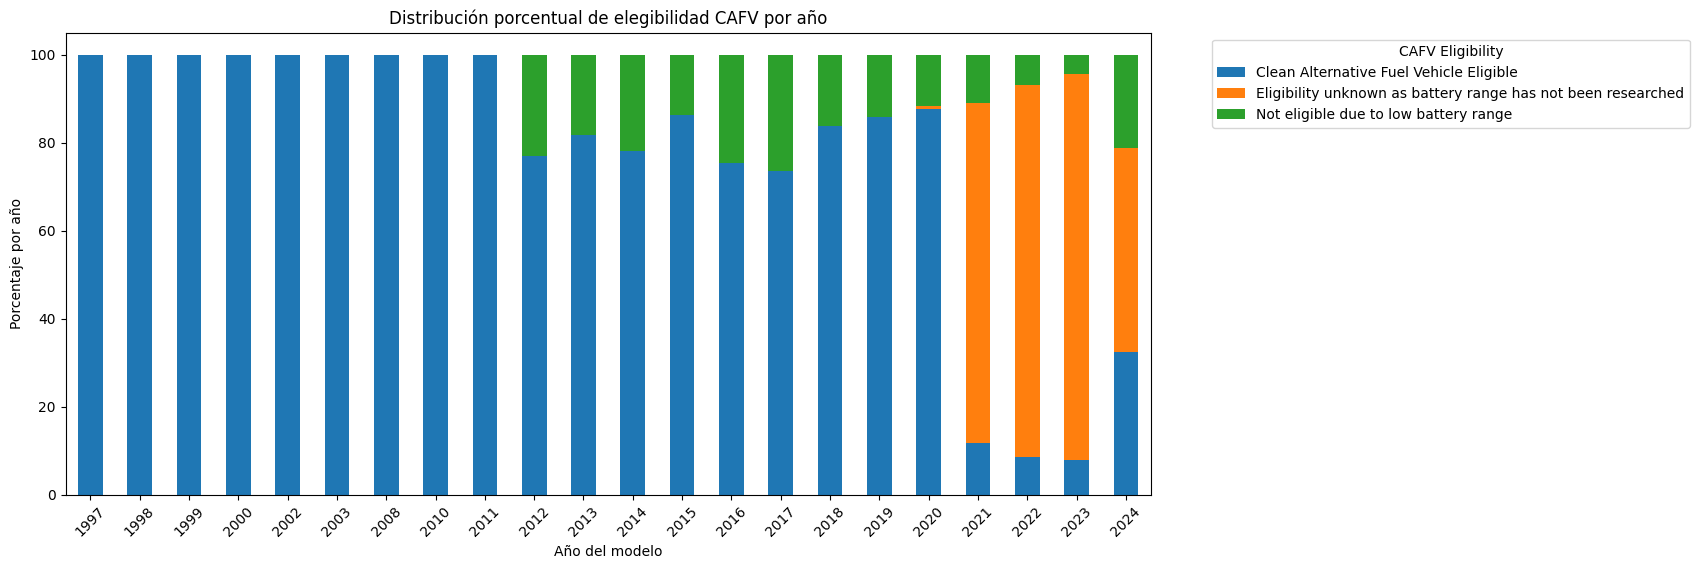

In [49]:
cafv_by_year_pct.plot(kind="bar", stacked=True, figsize=(14,6))

plt.title("Distribución porcentual de elegibilidad CAFV por año")
plt.xlabel("Año del modelo")
plt.ylabel("Porcentaje por año")
plt.xticks(rotation=45)
plt.legend(title="CAFV Eligibility", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

El grafico muestra lo que veniamos analizando, una creciente subida en los ultimos años sobre elegibilidad desconocida, efecto de lo poco estudiado que se tiene las baterias del año 2021 en adelante, esto no quiere decir que haya menor adopcion, si no, que hace falta informacion relacionada con las baterias, de la misma manera, debemos tomar en cuenta que 2024 parece ser un año sesgado dentro del dataset.

### Modelo ML
Variable objetivo: EV Count, vamos a entrenar el modelo para predecir como crecera la adopcion de autos electricos
Variable predictoria: Model year


In [53]:
adoption_by_year = (
    df_ev_cleaned["Model Year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

adoption_by_year.columns = ["Model Year", "EV Count"]

# Excluir 2024 por año incompleto
adoption_model = adoption_by_year[adoption_by_year["Model Year"] <= 2023].copy()

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

X = adoption_model[["Model Year"]]
y = adoption_model["EV Count"]

linear_model = LinearRegression()
linear_model.fit(X, y)

linear_pred = linear_model.predict(X)

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X, y)

poly_pred = poly_model.predict(X)

print("Regresión lineal")
print("R2:", r2_score(y, linear_pred))
print("MAE:", mean_absolute_error(y, linear_pred))

print("Regresión polinomial")
print("R2:", r2_score(y, poly_pred))
print("MAE:", mean_absolute_error(y, poly_pred))

Regresión lineal
R2: 0.4506509479643783
MAE: 6779.175208845774
Regresión polinomial
R2: 0.7649817132630139
MAE: 4254.387314572221


Para la etapa de aprendizaje automático se implementó un modelo de regresión con el objetivo de predecir el crecimiento futuro del número de vehículos eléctricos registrados. Debido a que el análisis exploratorio mostró una tendencia creciente en la adopción de vehículos eléctricos, se utilizó Model Year como variable predictora y el conteo anual de vehículos como variable objetivo.

Se excluyó el año 2024 del entrenamiento debido a que el dataset parece contener información parcial de ese año, lo que podría introducir un sesgo artificial en el modelo. Además, se comparó una regresión lineal con una regresión polinomial de segundo grado para evaluar si el crecimiento del mercado se comporta de forma lineal o acelerada.

***Regresion lineal y regresion polinomial***

Los resultados muestran que el crecimiento de vehículos eléctricos no sigue una tendencia estrictamente lineal. La regresión polinomial obtuvo un mejor desempeño, con un R² de 0.765 y un MAE de 4,254 vehículos, frente a un R² de 0.451 y un MAE de 6,779 vehículos en la regresión lineal. Esto sugiere que la adopción de vehículos eléctricos presenta un comportamiento acelerado, especialmente en los años recientes.

In [55]:
future_years = pd.DataFrame({
    "Model Year": [2024, 2025, 2026]
})

future_pred = poly_model.predict(future_years)

future_results = pd.DataFrame({
    "Model Year": future_years["Model Year"],
    "Predicted EV Count": future_pred.astype(int)
})

future_results

,Model Year,Predicted EV Count
0,2024,39366
1,2025,44351
2,2026,49599


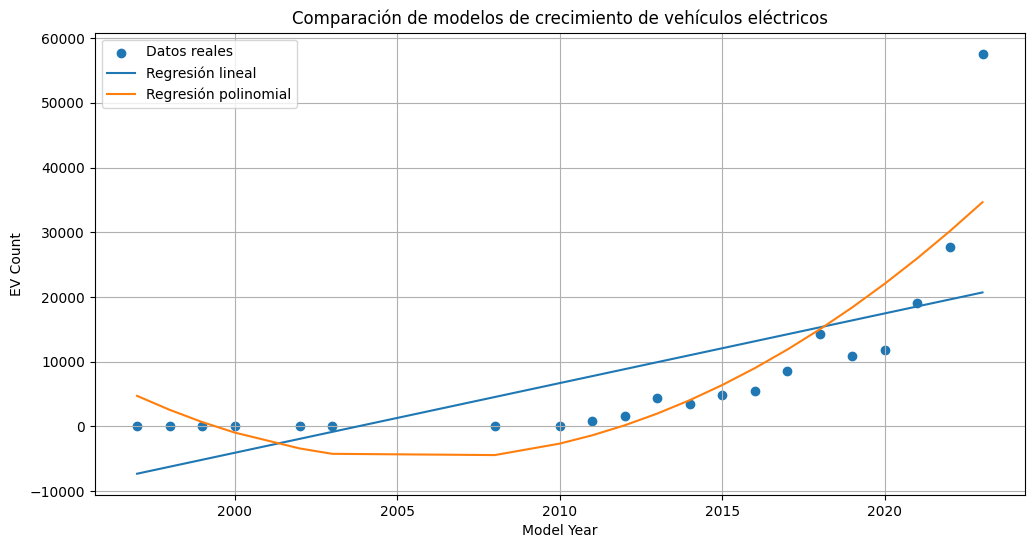

In [56]:
plt.figure(figsize=(12,6))

plt.scatter(X, y, label="Datos reales")
plt.plot(X, linear_pred, label="Regresión lineal")
plt.plot(X, poly_pred, label="Regresión polinomial")

plt.title("Comparación de modelos de crecimiento de vehículos eléctricos")
plt.xlabel("Model Year")
plt.ylabel("EV Count")
plt.legend()
plt.grid(True)
plt.show()

Los registros anteriores a 2011 representan una fase experimental y de adopción temprana del mercado de vehículos eléctricos, con volúmenes extremadamente reducidos. Debido a que el objetivo del modelo es analizar el crecimiento moderno del mercado, se construye una segunda versión utilizando únicamente los años 2011-2023, periodo en el que se observa una adopción significativa y sostenida.

In [57]:
adoption_recent = adoption_model[
    adoption_model["Model Year"] >= 2011
].copy()

X_recent = adoption_recent[["Model Year"]]
y_recent = adoption_recent["EV Count"]

In [58]:
adoption_recent["Growth %"] = (
    adoption_recent["EV Count"]
    .pct_change() * 100
)

adoption_recent

,Model Year,EV Count,Growth %
8,2011,775,NaN
9,2012,1618,108.774194
10,2013,4408,172.435105
11,2014,3509,-20.394737
12,2015,4844,38.045027
13,2016,5483,13.191577
14,2017,8559,56.100675
15,2018,14322,67.332632
16,2019,10939,-23.621003
17,2020,11768,7.578389


In [59]:
linear_recent = LinearRegression()
linear_recent.fit(X_recent, y_recent)

linear_recent_pred = linear_recent.predict(X_recent)

poly_recent = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_recent.fit(X_recent, y_recent)

poly_recent_pred = poly_recent.predict(X_recent)

print("Regresión lineal reciente")
print("R2:", r2_score(y_recent, linear_recent_pred))
print("MAE:", mean_absolute_error(y_recent, linear_recent_pred))

print("Regresión polinomial reciente")
print("R2:", r2_score(y_recent, poly_recent_pred))
print("MAE:", mean_absolute_error(y_recent, poly_recent_pred))

Regresión lineal reciente
R2: 0.6434053830050245
MAE: 6209.13186813196
Regresión polinomial reciente
R2: 0.8348968462738122
MAE: 4989.862138931568


Al limitar el análisis al periodo 2011-2023, la regresión polinomial obtuvo el mejor desempeño, con un R² de 0.835 y un MAE de aproximadamente 4,990 vehículos. Esto indica que el modelo logra explicar cerca del 83.5% de la variabilidad del crecimiento anual, capturando mejor la aceleración reciente del mercado que una regresión lineal.



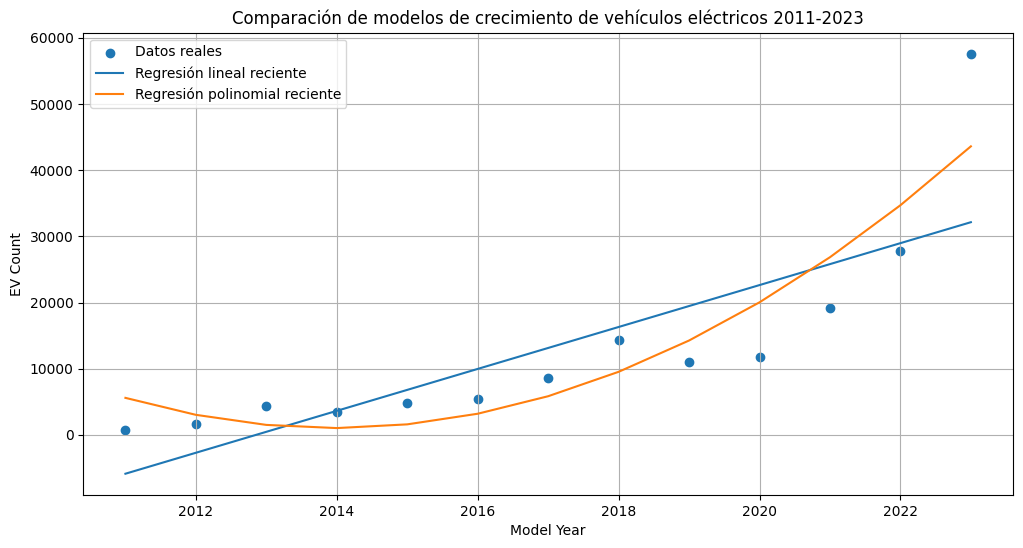

In [60]:
plt.figure(figsize=(12,6))

plt.scatter(X_recent, y_recent, label="Datos reales")
plt.plot(X_recent, linear_recent_pred, label="Regresión lineal reciente")
plt.plot(X_recent, poly_recent_pred, label="Regresión polinomial reciente")

plt.title("Comparación de modelos de crecimiento de vehículos eléctricos 2011-2023")
plt.xlabel("Model Year")
plt.ylabel("EV Count")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
future_years = pd.DataFrame({
    "Model Year": [2024, 2025, 2026]
})

future_pred = poly_recent.predict(future_years)

pd.DataFrame({
    "Model Year": future_years["Model Year"],
    "Predicted EV Count": future_pred.astype(int)
})

,Model Year,Predicted EV Count
0,2024,53531
1,2025,64511
2,2026,76533


***Conclusion modelo de ML***

Con base en el modelo de regresión polinomial entrenado sobre el periodo 2011-2023, se proyecta que el número de vehículos eléctricos podría continuar aumentando en los próximos años. El modelo estima aproximadamente 53,531 registros para 2024, 64,511 para 2025 y 76,533 para 2026.

Estas predicciones deben interpretarse como una aproximación basada en la tendencia histórica, no como valores exactos. Además, el dato real disponible de 2024 en el dataset parece estar incompleto, por lo que la predicción del modelo puede servir como referencia para estimar el potencial cierre anual.

El modelo sugiere que continuara un crecimiento sostenido, lo que debe sugerir a las empresas constructoras de automoviles que deben prepararse para mejorar sus plataformas y a su vez, construir mas automoviles.

Recomendaciones:
- Basado en el modelo, se debe priorizar sobre los autos BEV, dado que muestran una mayor tendencia de adopcion
- Invertir en infresctructura de carga de baterias en las ciudades que muestran una mayor adopcion, sin deja de lado las demas ciudades. Se debe tomar en cuenta que conforme mayor cantidad de autos, mayor necesidad de carga se tendra.
- Se puede aprovechar los incentivos gubernamentales, beneficios que dan a las empresas por adopcion a energias mas limpias.
